In [1]:
# Install SHAP if not already installed
import subprocess
subprocess.run(["pip", "install", "shap"])
print("Done")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 11.3 MB/s  0:00:01eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.1━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
    Uninstalling numpy-2.4.1:0m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
      Successfully uninstalled numpy-2.4.1╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]

  You can safely remove it manually.


   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]

  You can safely remove it manually.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━ 2/3 [shap]
Done


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

In [3]:
# Load the engineered dataset
df_model = pd.read_csv("/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/engineered_features.csv")
df_model.head()

,Tenure Group,Charge Level,Multiple Lines,Tech Support,Internet Service,Online Security,Contract,Churn
0,0,0,0,0,1,0,0,0
1,1,1,0,0,1,1,1,0
2,0,1,0,0,1,1,0,1
3,2,1,0,1,1,1,1,0
4,0,2,0,0,2,0,0,1


In [4]:
# Split features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Features:", X.columns.tolist())

Features: ['Tenure Group', 'Charge Level', 'Multiple Lines', 'Tech Support', 'Internet Service', 'Online Security', 'Contract']


In [5]:
# Train test split — 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 4922
Test samples: 2110


In [6]:
# Apply SMOTETomek
from imblearn.combine import SMOTETomek
smotetomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smotetomek.fit_resample(X_train, y_train)

print("Class distribution after SMOTETomek:")
print(pd.Series(y_train_balanced).value_counts())

Class distribution after SMOTETomek:
Churn
1    3614
0    3614
Name: count, dtype: int64


In [7]:
# Rebuild the tuned hybrid using the best parameters found during tuning
# Best LR params: C=0.01, solver=lbfgs
# Best SVM params: C=10, kernel=linear
# Best XGBoost params: learning_rate=0.1, max_depth=5, n_estimators=100

lr_tuned = LogisticRegression(C=0.01, solver="lbfgs", random_state=42)
svm_tuned = SVC(C=10, kernel="linear", probability=True, random_state=42)
xgb_tuned = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100,
                           random_state=42, eval_metric="logloss")

tuned_hybrid = VotingClassifier(
    estimators=[
        ("lr", lr_tuned),
        ("svm", svm_tuned),
        ("xgb", xgb_tuned)
    ],
    voting="soft"
)

tuned_hybrid.fit(X_train_balanced, y_train_balanced)
print("Tuned hybrid model rebuilt and trained successfully")

Tuned hybrid model rebuilt and trained successfully


In [8]:
# SHAP works best on individual models rather than voting ensembles
# We use XGBoost from inside the hybrid since it had the highest
# individual cross validation AUC of 0.85 during tuning
# This gives us the most reliable SHAP values for explanation

xgb_tuned.fit(X_train_balanced, y_train_balanced)
print("XGBoost model trained for SHAP analysis")

XGBoost model trained for SHAP analysis


In [9]:
# Create the SHAP explainer for XGBoost
# TreeExplainer is the fastest and most accurate explainer for tree-based models
explainer = shap.TreeExplainer(xgb_tuned)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated successfully
Shape of SHAP values: (2110, 7)


In [10]:
# Feature names for the charts
feature_names = X.columns.tolist()
print("Features being explained:", feature_names)

Features being explained: ['Tenure Group', 'Charge Level', 'Multiple Lines', 'Tech Support', 'Internet Service', 'Online Security', 'Contract']


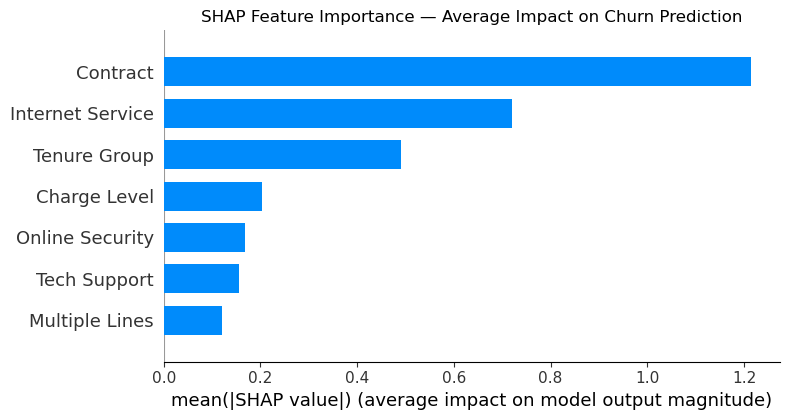

In [11]:
# 1. SHAP Summary Plot — Bar Chart
# Shows the average impact of each feature on predictions
# The longer the bar the more important the feature overall
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Average Impact on Churn Prediction")
plt.tight_layout()
plt.show()

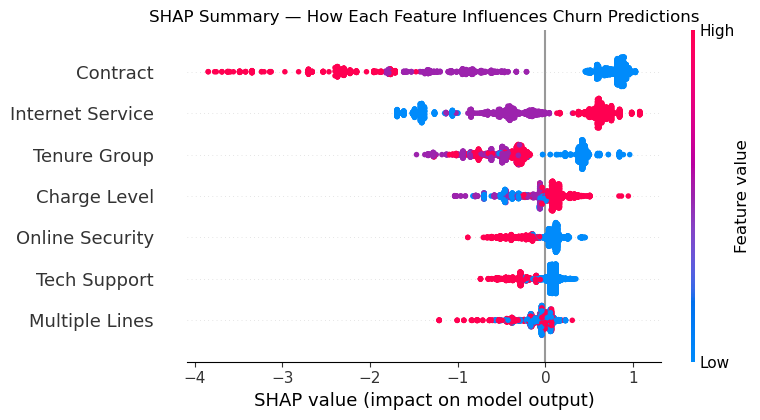

In [12]:
# 2. SHAP Summary Plot — Dot Plot
# Each dot represents one customer
# Red dots = high feature value, Blue dots = low feature value
# Dots on the right = pushed prediction toward churn
# Dots on the left = pushed prediction away from churn
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  show=False)
plt.title("SHAP Summary — How Each Feature Influences Churn Predictions")
plt.tight_layout()
plt.show()

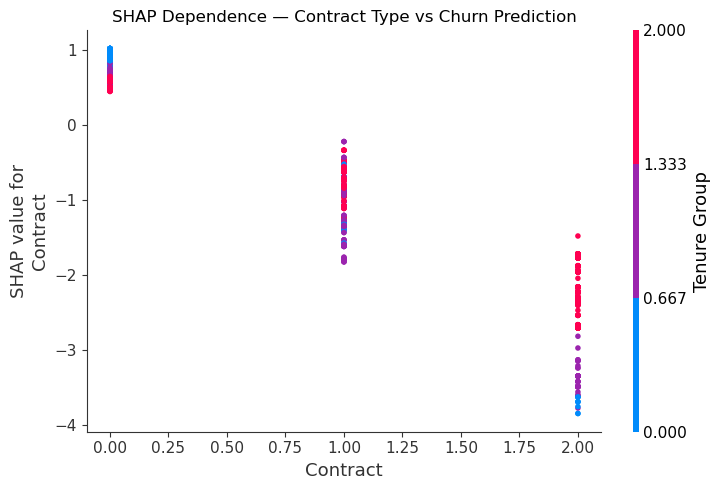

In [13]:
# 3. SHAP Dependence Plot for Contract
# Shows how the Contract feature specifically influences churn predictions
# across different contract types (0=Month-to-Month, 1=One Year, 2=Two Year)
shap.dependence_plot("Contract", shap_values, X_test,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence — Contract Type vs Churn Prediction")
plt.tight_layout()
plt.show()

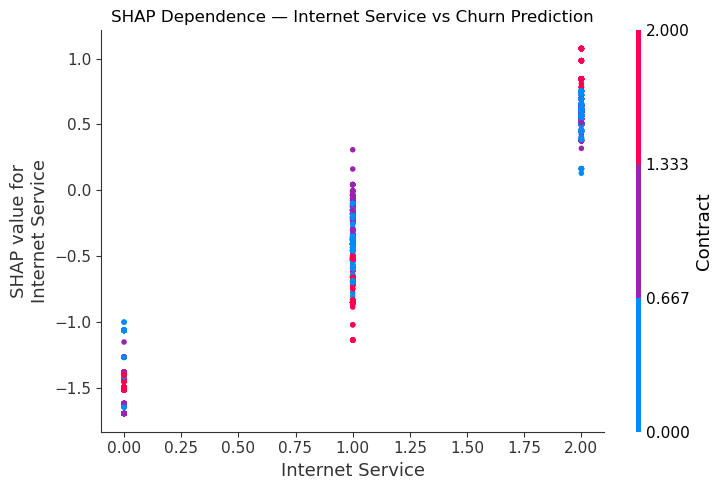

In [14]:
# 4. SHAP Dependence Plot for Internet Service
# Shows how Internet Service type influences churn predictions
# (0=No Internet, 1=DSL, 2=Fiber Optic)
shap.dependence_plot("Internet Service", shap_values, X_test,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence — Internet Service vs Churn Prediction")
plt.tight_layout()
plt.show()

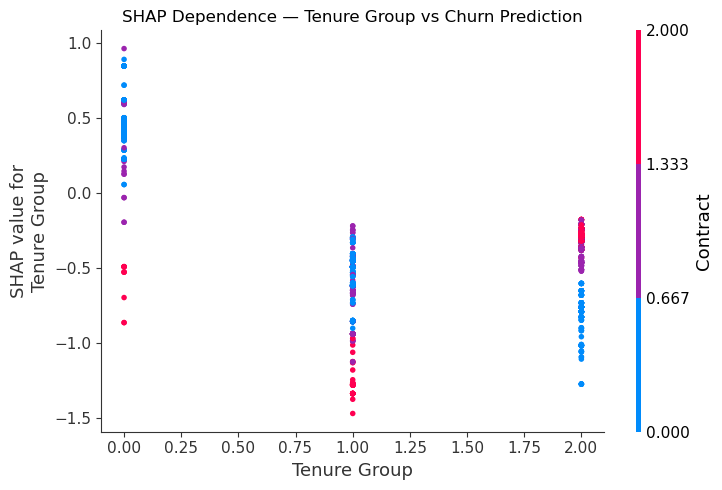

In [15]:
# 5. SHAP Dependence Plot for Tenure Group
# Shows how customer loyalty stage influences churn predictions
# (0=New, 1=Established, 2=Loyal)
shap.dependence_plot("Tenure Group", shap_values, X_test,
                     feature_names=feature_names, show=False)
plt.title("SHAP Dependence — Tenure Group vs Churn Prediction")
plt.tight_layout()
plt.show()

In [16]:
# 6. SHAP Force Plot for a single customer prediction
# Pick the first customer in the test set as an example
# This shows exactly which features pushed the prediction
# toward churn and which pushed it away for that one customer
shap.initjs()

customer_index = 0
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test.iloc[customer_index],
    feature_names=feature_names
)

# Save force plot as HTML file to view in browser
shap.save_html(
    "/home/ae7ba225-76ef-4005-aee2-7847a70630ed/SilentTelecomChurn/shap_force_plot.html",
    force_plot
)
print("Force plot saved as shap_force_plot.html")
print()
print("Customer details:")
print(X_test.iloc[customer_index])
print()
print("Actual Churn:", y_test.iloc[customer_index])
print("Predicted Churn:", tuned_hybrid.predict(X_test.iloc[[customer_index]])[0])

Force plot saved as shap_force_plot.html

Customer details:
Tenure Group        2
Charge Level        0
Multiple Lines      1
Tech Support        0
Internet Service    0
Online Security     0
Contract            2
Name: 2476, dtype: int64

Actual Churn: 0
Predicted Churn: 0


In [17]:
# 7. SHAP Summary Table — which features matter most
# Average absolute SHAP value per feature
mean_shap = pd.DataFrame({
    "Feature": feature_names,
    "Mean SHAP Value": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean SHAP Value", ascending=False)

mean_shap["Rank"] = range(1, len(mean_shap) + 1)
mean_shap = mean_shap[["Rank", "Feature", "Mean SHAP Value"]]
mean_shap["Mean SHAP Value"] = mean_shap["Mean SHAP Value"].round(4)

print("Feature Importance Ranking from SHAP Analysis:")
print(mean_shap.to_string(index=False))

Feature Importance Ranking from SHAP Analysis:
 Rank          Feature  Mean SHAP Value
    1         Contract           1.2136
    2 Internet Service           0.7193
    3     Tenure Group           0.4916
    4     Charge Level           0.2042
    5  Online Security           0.1684
    6     Tech Support           0.1565
    7   Multiple Lines           0.1208
